# 1. Explore pre-trained word vectors. Explore word relationships using vector arithmetic. Perform arithmetic operations and analyze results.

In [9]:
# !pip install gensim

from gensim.downloader import load

print ('Loading pre-trained Glove model (50 dimensions)...')

model = load ("glove-wiki-gigaword-50")

def ewr () :
    result = model.most_similar (
        positive = ['king', 'woman'],
        negative = ['man'],
        topn = 1
    )

    print ('\nKing - Man + Woman = ?', result [0][0])
    print ('Similarity: ', result [0][1])

    result = model.most_similar (
        positive = ['paris', 'italy'],
        negative = ['france'],
        topn = 1
    )

    print ('\nParis - France + Italy = ?', result [0][0])
    print ('Similairity: ', result [0][1])

    result = model.most_similar (
        positive = ['programming'],
        topn = 5
    )

    print ("\nTop 5 words similar to 'programming'")

    for word, similarity in result : print (word, similarity)

ewr ()

print ('\n-- End of Execution --')


Loading pre-trained Glove model (50 dimensions)...

King - Man + Woman = ? queen
Similarity:  0.8523604273796082

Paris - France + Italy = ? rome
Similairity:  0.8465589284896851

Top 5 words similar to 'programming'
network 0.7707955241203308
interactive 0.7613597512245178
format 0.7584694623947144
channels 0.753067672252655
networks 0.752894937992096

-- End of Execution --


# 2. Use dimensionality reduction (e.g., PCA or t-SNE) to visualize word embeddings for Q 1. Select 10 words from a specific domain (e.g., sports, technology) and visualize their embeddings. Analyze clusters and relationships. Generate contextually rich outputs using embeddings. Write a program to generate 5 semantically similar words for a given input.

Loading pre-trained Glove Model (50 dimensions)...



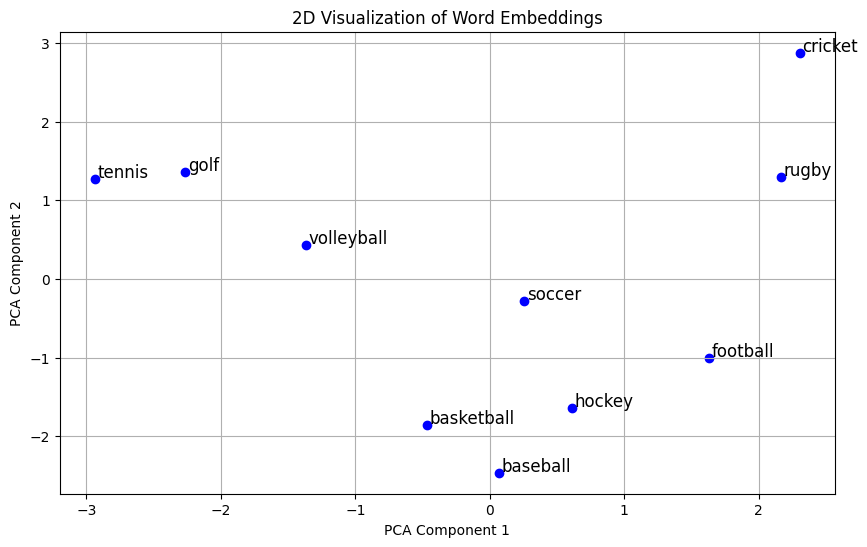

2D Visualization of Word Embeddings saved as 'wordembeddings.png'

Top 5 words similar to 'programming': 
network (0.770796)
interactive (0.761360)
format (0.758469)
channels (0.753068)
networks (0.752895)

-- End of Execution --


In [8]:
# if gensim is not installed, use the below line and run, wait about a few minutes for it to install
# !pip install gensim
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from gensim.downloader import load

def reduce_dimensions (embeddings) : # Using PCA
    pca = PCA (n_components = 2)
    reduced_embeddings = pca.fit_transform (embeddings)

    return reduced_embeddings

def visualize_embeddings (words, reduced_embeddings) :
    plt.figure (figsize = (10, 6))
 
    for i, word in enumerate (words) :
        x, y = reduced_embeddings [i]
 
        plt.scatter (x, y, color = 'blue', marker = 'o')
        plt.text (x + 0.02, y + 0.02, word, fontsize = 12)
        
    plt.title ('2D Visualization of Word Embeddings')

    plt.xlabel ('PCA Component 1')
    plt.ylabel ('PCA Component 2')

    plt.grid (True)

    plt.savefig ('word-embeddings.png', dpi = 300, bbox_inches = 'tight')

    plt.show ()
    
    print ("2D Visualization of Word Embeddings saved as 'word-embeddings.png'")

def get_similar_words (word, model) :
    print (f"\nTop 5 words similar to '{word}': ")
    similar_words = model.most_similar (word, topn = 5)

    for similar_word, similarity in similar_words :
        print (f"{similar_word} ({similarity:.6f})")

    print ('\n-- End of Execution --')

print ('Loading pre-trained Glove Model (50 dimensions)...\n')

model = load ("glove-wiki-gigaword-50")
words = ['football', 'basketball', 'soccer', 'tennis', 'cricket', 'hockey', 'baseball', 'golf', 'volleyball', 'rugby']

embeddings = [model [word] for word in words]
reduced_embeddings = reduce_dimensions (embeddings)
visualize_embeddings (words, reduced_embeddings)

get_similar_words ('programming', model)


# 3. Train a custom Word2Vec model on a small dataset. Train embeddings on a domain-specific corpus (e.g., legal, medical) and analyze how embeddings capture domain-specific semantics.

Please wait a moment...



Enter a word:  patient



Words similar to 'patient': 
1. invasive (Similarity:  0.9524)
2. the (Similarity:  0.9078)
3. antibiotics (Similarity:  0.8369)
4. published (Similarity:  0.6993)
5. abnormalities (Similarity:  0.5822)




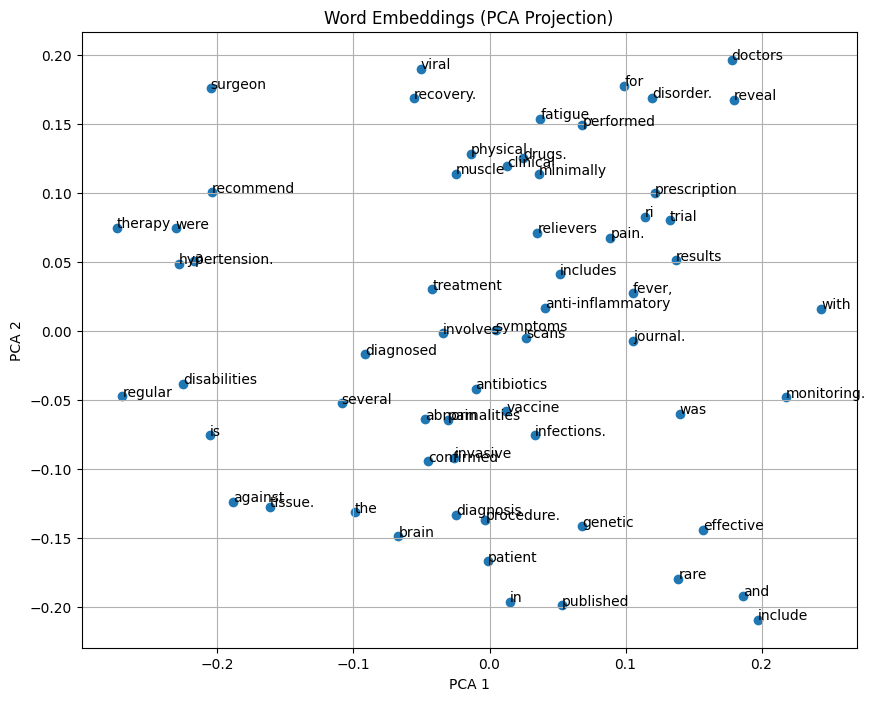

Word Embeddings (PCA Projection) saved as 'word2vec.png'

-- End of Execution --


In [10]:
# !pip install gensim

import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

corpus = [
    "The patient was diagnosed with disabilities and hypertension.",
    "RI scans reveal abnormalities in the brain tissue.",
    "The treatment involves antibiotics and regular monitoring.",
    "Symptoms include fever, fatigue, and muscle pain.",
    "The vaccine is effective against several viral infections.",
    "Doctors recommend physical therapy for recovery.",
    "The clinical trial results were published in the journal.",
    "The surgeon performed a minimally invasive procedure.",
    "The prescription includes pain relievers and anti-inflammatory drugs.",
    "The diagnosis confirmed a rare genetic disorder."]

tokenized_corpus = [sentence.lower ().split ()    for sentence    in corpus]

model = Word2Vec (sentences   = tokenized_corpus,
                  vector_size = 5, window = 2,
                  min_count   = 1, epochs = 5)

print ('Please wait a moment...\n')
word = input ('Enter a word: ').lower ()

if word in model.wv :
    similar = model.wv.most_similar (word, topn = 5)

    print (f"\nWords similar to '{word}': ")

    for i, (w, score) in enumerate (similar, 1) : print (f"{i}. {w} (Similarity: {score: .4f})")
else : print ('Word not found in vocabulary!')

words = list (model.wv.index_to_key)
word_vectors = model.wv [words]

pca = PCA (n_components = 2)

result = pca.fit_transform (word_vectors)

plt.figure (figsize = (10, 8))
plt.scatter (result [:, 0], result [:, 1]) 

for i, word in enumerate (words) :
    plt.annotate (word, xy = (result [i, 0], result [i, 1]))

plt.title ('Word Embeddings (PCA Projection)')

plt.xlabel ('PCA 1')
plt.ylabel ('PCA 2')

plt.grid (True)

plt.savefig ('word2vec.png', dpi = 300, bbox_inches = 'tight'); print ('\n')

plt.show ()

print ("Word Embeddings (PCA Projection) saved as 'word2vec.png'\n\n-- End of Execution --")


# 4. Use word embeddings to improve prompts for Generative AI model. Retrieve similar words using word embeddings. Use the similar words to enrich a GenAI prompt. Use the AI model to generate responses for the original and enriched prompts. Compare the outputs in terms of detail and relevance.

In [3]:
# !pip install cohere gensim

import cohere
import gensim.downloader as api

# Replace with your actual API key
co = cohere.Client ("YOUR_COHERE_API_KEY")

print ("\nLoading word embeddings...")
model = api.load ("glove-wiki-gigaword-100")
print ("Model loaded successfully.")

prompt = "write an essay on natural disaster"

def get_first_enriched_prompt (prompt, topn = 3) :
    words = prompt.split ()
    enriched_words = []
    
    for i, word in enumerate (words) :
        clean_word = word.strip ('.,!?').lower ()
        
        try :
            similar_words = model.most_similar (clean_word, topn = topn)
            
            if similar_words :
                sim_word  = similar_words [0][0]

                if word [0].isupper () :
                    sim_word = sim_word.capitalize ()
                enriched_words.append (sim_word)
            else : enriched_words.append (word)
        except : enriched_words.append (word)

    return ' '.join (enriched_words)

def get_response (text) :
    try :
        response    = co.chat (model   = "command-a-03-2025",  # recommended chat model
                               message = text, # set message type and preamble for the valid output response
                               preamble = "Write a comprehensive,
                                           well-structured essay with clear introduction,
                                           body paragraphs, and conclusion.
                                           Be informative and use an academic tone."
                              )
        return response.text.strip ()
        
    except Exception as e : return f"Error: {e}"  # Fixed f-string

print (f"\nOriginal Prompt: \n{prompt}\nResponse:\n{get_response(prompt)}")

enriched_prompt = get_first_enriched_prompt (prompt)

if enriched_prompt : print (f"\nEnriched Prompt: \n{enriched_prompt}\nResponse: \n{get_response(enriched_prompt)}")
else               : print ("\nNo enriched prompt could be generated!")


Loading word embeddings...
Model loaded successfully.

Original Prompt: 
write an essay on natural disaster
Response:
**Natural Disasters: Causes, Impacts, and Mitigation**

Natural disasters are catastrophic events caused by natural processes of the Earth, often resulting in significant loss of life, property, and environmental damage. These events, which include earthquakes, hurricanes, floods, tsunamis, wildfires, and volcanic eruptions, are an inherent part of the planet's geological and meteorological systems. While humans cannot prevent natural disasters, understanding their causes, impacts, and implementing effective mitigation strategies can reduce their devastating effects.

### **Causes of Natural Disasters**

Natural disasters are primarily driven by geological, meteorological, and hydrological forces. Earthquakes, for instance, occur due to the sudden release of energy in the Earth's crust, often along fault lines. Volcanic eruptions are the result of magma rising from the 

# 5. Use word embeddings to create meaningful sentences for creative tasks. Retrieve similar words for a seed word. Create a sentence or story using these words as a starting point. Write a program that: Takes a seed word. Generates similar words. Constructs a short paragraph using these words.

In [3]:
# !pip install gensim

from gensim.downloader import load
import random

print ('Loading pre-trained Glove model (50 dimensions)...')

model = load ("glove-wiki-gigaword-50")

print ('Model loaded successfully.\n')

def create_paragraph (iw, sws) :
    paragraph = 'The topic of (iw) is fascinating, often linked to terms like '
    random.shuffle (sws)

    for word in sws : paragraph += str (word) + ", "

    paragraph = paragraph.rstrip (", ") + "."

    return paragraph

iw =  'hacking'
sws = model.most_similar (iw, topn = 5)
words = [word for word, s in sws]

paragraph = create_paragraph (iw, words)

print (paragraph)


Loading pre-trained Glove model (50 dimensions)...
Model loaded successfully.

The topic of (iw) is fascinating, often linked to terms like hacked, malicious, hacker, snooping, hackers.


# 6. Use a pre-trained Hugging Face model to analyze sentiment in text. Assume a real-world application, Load the sentiment analysis pipeline. Analyze the sentiment by giving sentences to input.

In [17]:
# install transformers if not already installed
# !pip install transformers torch

from transformers import pipeline
import warnings
warnings.filterwarnings ('ignore')

sentiment_analyzer = pipeline ('sentiment-analysis',
                                model = 'distilbert-base-uncased-finetuned-sst-2-english',
                                device = -1  # -1 for CPU, 0 for GPU if available
                              )

print ('\nSentiment Analysis of Text Input')

while True :    
    user_input = input ("\nEnter a sentence (or type 'exit' to quit): ")

    if user_input.lower () == "exit" : print ('Goodbye!\n\n-- End of Execution --'); break

    if not user_input.strip () : print ('Please enter a non-empty sentence.'); continue

    result = sentiment_analyzer (user_input) [0]

    print (f"\nLabel: {result ['label']}")
    print (f"Confidence: {result ['score']: .4f}")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Sentiment Analysis of Text Input



Enter a sentence (or type 'exit' to quit):  You are a nice guy!



Label: POSITIVE
Confidence:  0.9999



Enter a sentence (or type 'exit' to quit):  I dislike you very much!



Label: NEGATIVE
Confidence:  0.9984



Enter a sentence (or type 'exit' to quit):  exit


Goodbye!

-- End of Execution --


# 7. Summarize long texts using a pre-trained summarization model using Hugging face model. Load the summarization pipeline. Take a passage as input and obtain the summarized text.

In [9]:
# !pip install transformers torch

from transformers import BartTokenizer, BartForConditionalGeneration
import warnings
warnings.filterwarnings ('ignore')

print ("Testing BART-large...")
model     = BartForConditionalGeneration.from_pretrained ("facebook/bart-large-cnn")
tokenizer = BartTokenizer.from_pretrained                ("facebook/bart-large-cnn")
print ("Model is ready!\n")

test_text = """
The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France. 
It is named after the engineer Gustave Eiffel, whose company designed and built the tower. 
Constructed from 1887 to 1889 as the entrance to the 1889 World's Fair, it was initially 
criticized by some of France's leading artists and intellectuals for its design, but it 
has become a global cultural icon of France and one of the most recognizable structures 
in the world. The tower is the most-visited paid monument in the world and receives 
approximately 7 million visitors annually. It stands 330 meters tall and was the tallest 
man-made structure in the world for 41 years until the Chrysler Building was completed 
in New York in 1930.
"""

print (f"Original text word count: {len (test_text.split ())} words\n")

inputs = tokenizer (test_text,
                    return_tensors = "pt",
                    max_length = 1024,
                    truncation = True)

summary_ids = model.generate (inputs ["input_ids"],
                              max_length = 80,          min_length = 30,
                              num_beams = 8,            early_stopping = True,
                              length_penalty = 0.8,     no_repeat_ngram_size = 3,
                              repetition_penalty = 1.2, do_sample = False
              )

summary = tokenizer.decode (summary_ids [0], skip_special_tokens = True)

print ("Summary:\n" + summary + "\n")
print (f"Summary word count: {len (summary.split ())} words")
print ('\n-- End of Execution --')


Testing BART-large...


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Model is ready!

Original text word count: 124 words

Summary:
The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France. constructed from 1887 to 1889 as the entrance to the 1889 World's Fair. The tower is the most-visited paid monument in the world and receives approximately 7 million visitors annually.

Summary word count: 46 words

-- End of Execution --


# 8. Install langchain, cohere (for key), langchain-community. Get the api key (By logging into Cohere and obtaining the cohere key). Load a text document from your google drive. Create a prompt template to display the output in a particular manner.

In [5]:
# Install required libraries
# !pip install -q langchain langchain-community langchain-core cohere

import os
from langchain_community.document_loaders import TextLoader
from langchain_core.prompts import PromptTemplate
from langchain_cohere import ChatCohere

# Check if text file is in you directory
print (os.getcwd ())
print (os.listdir ())

find_path = os.path.exists ("sample_text.txt")

if find_path == 0 : 
    with open ("sample_text.txt", "w") as file :
        file.write (
            "Artificial Intelligence is transforming industries by automating tasks and improving decision making."
        )

print ("\nsample_text.txt has been loaded successfully!\n\n")

# Load text document
text = TextLoader ("sample_text.txt").load () [0].page_content

# Create prompt template
prompt = PromptTemplate (input_variables = ["text"],
                         template = """
You are an AI assistant.

Summarize the following text in 5 concise points.

Text:
{text}

Summary:
"""
)

# Initialize Cohere LLM
YOUR_COHERE_API_KEY = "api-key" # if not working, use a new key from your Cohere dashboard

llm = ChatCohere (
                  cohere_api_key = YOUR_COHERE_API_KEY,
                  model = "command-r7b-12-2024"
                 )

# Modern LangChain Expression Language (LCEL)
chain = prompt | llm

# Run chain (uses Cohere tokens, use wisely)
response = chain.invoke ({"text": text})

# Print output
print ("\nSummary:\n", response.content) # (optional) get extended chat logs and token usage metrics


C:\Users\HP\Gen AI Lab
['.ipynb_checkpoints', 'Generative_Workspace.ipynb', 'sample_text.txt', 'word-embeddings.png', 'word2vec.png']

sample_text.txt has been loaded successfully!



Summary:

content='Here is a summary of the text in 5 concise points:\n\n1. Artificial Intelligence (AI) is a powerful tool.\n2. AI automates tasks, increasing efficiency and productivity.\n3. AI enhances decision-making processes, leading to better outcomes.\n4. Its impact is felt across various industries.\n5. AI is revolutionizing the way businesses operate and function.' additional_kwargs={'id': '4de8a83f-e08b-47a4-83f0-523222acd21d', 'finish_reason': 'COMPLETE', 'token_count': {'input_tokens': 538.0, 'output_tokens': 80.0}} response_metadata={'id': '4de8a83f-e08b-47a4-83f0-523222acd21d', 'finish_reason': 'COMPLETE', 'token_count': {'input_tokens': 538.0, 'output_tokens': 80.0}} id='lc_run--019e2225-a2cb-7372-8d50-163cbe9b0f2c-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 538,

# 9. Take the Institution name as input. Use Pydantic to define the schema for the desired output and create a custom output parser. Invoke the Chain and Fetch Results. Extract the below Institution related details from Wikipedia: The founder of the Institution. When it was founded. The current branches in the institution . How many employees are working in it. A brief 4-line summary of the institution.

In [19]:
# CODE 2 (Works most of the time)
# =====================================================
# Step 0: Install and import required libraries/assests
# !pip install wikipedia pydantic

import wikipedia, requests, re

from bs4 import BeautifulSoup
from pydantic import BaseModel

# Step 1: Define Pydantic Schema
class Institution (BaseModel) :
    name        : str
    founder     : str   = "Not Found"
    founded     : str   = "Not Found"
    branches    : list  = []
    employees   : str   = "Not Found"
    summary     : str   = ""

# Step 2: Custom Parser Function
def extract_info (soup) :
    info = {'founder' : None, 'founded' : None, 'employees' : None, 'branches' : []}
    
    for row in soup.select ('.infobox tr') :
        th = row.find ('th')
        td = row.find ('td')
        
        if not th or not td : continue
            
        header = th.get_text (strip = True).lower ()
        value  = td.get_text (strip = True)
        
        if 'founder' in header : info ['founder'] = re.sub (r'\[[^\]]*\]', '', value).strip ()
            
        elif 'founded' in header or 'established' in header :
            year               = re.search  (r'\b(18|19|20)\d{2}\b', value)
            info ['founded']   = year.group (0)           if year else value [:20]
            
        elif 'employees' in header or 'staff' in header :
            nums               = re.findall (r'\d+', value.replace (',', ''))
            info ['employees'] = nums [0]                 if nums else value [:20]
            
        elif 'campus' in header or 'branches' in header :
            info ['branches']  = [b.strip ()              for b in re.split (r'[;,·•\n]', value)        if b.strip ()]    [:3]
    
    return info

# Step 3: Main Fetch Function
def fetch_institution (name) :
    try :
        page    = wikipedia.page      (name,      auto_suggest = True)    # Get Wikipedia page
        summary = wikipedia.summary   (name,      sentences    = 4)
        
        response = requests.get   (page.url,      headers = {'User-Agent' : 'Mozilla/5.0'})
        soup     = BeautifulSoup  (response.text, 'html.parser')  # Parse HTML
        
        info = extract_info (soup) # Extract data
        
        return Institution (                   # Return validated object
            name      = page.title,
            founder   = info ['founder']     or "Not Found",
            founded   = info ['founded']     or "Not Found",
            branches  = info ['branches'],
            employees = info ['employees']   or "Not Found",
            summary   = summary [:400]       )
    except Exception as e :
        return Institution       (name = name,       summary = f"Error: {str (e) [:100]}")

# Step 4: Run the Program

print ("=" * 60)        # Headline
print ("WIKIPEDIA INSTITUTION INFO EXTRACTOR - Lab Exam")
print ("=" * 60)

name = input ("\nEnter institution name: ")   # User input
print (f"\nFetching data for '{name}'...\n")

result = fetch_institution (name)   # Detect user input and fetch institution data

# Display Results

print ("=" * 60)          # Headline initiation
print ("EXTRACTED DETAILS")
print ("=" * 60)

print (f"Name: {result.name}")       # Display info of institution
print (f"Founder: {result.founder}")
print (f"Founded: {result.founded}")
print (f"Branches: {', '.join (result.branches) if result.branches else 'Not Found'}")  # If "Branches" is not found, display "Not Found" as replacement string
print (f"Employees: {result.employees}")    # Count may vary with respect to edits in Wikipedia page, verify for accuracy

print (f"\nSummary:\n{result.summary}")    # Make a summary of the institution

print ("\n" + "=" * 60)    # Ending of info


WIKIPEDIA INSTITUTION INFO EXTRACTOR - Lab Exam



Enter institution name:  Harvard University



Fetching data for 'Harvard University'...

EXTRACTED DETAILS
Name: Harvard University
Founder: Massachusetts General Court
Founded: October 28, 1636(389
Branches: 209 acres (85 ha)Midsize city[10]
Employees: 2400

Summary:
Harvard University is a private Ivy League research university in Cambridge, Massachusetts, United States. Founded in 1636, and named Harvard College in 1639 in honor of its first benefactor, Puritan clergyman John Harvard, it is the oldest institution of higher learning in the United States. Its influence, wealth, and rankings have made it one of the most prestigious universities in the world.
Ha



# 10. Build a chatbot for the Indian Penal Code. We'll start by downloading the official Indian Penal Code document, and then we'll create a chatbot that can interact with it. Users will be able to ask questions about the Indian Penal Code and have a conversation with it.

In [21]:
# Install the PDF document and Faiss library (ignore the line if already installed)
# !pip install pymupdf
# !pip install faiss-cpu
# !pip install sentence-transformers

import fitz, faiss, numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings ('ignore')

# Download the pdf from the link given below
# https://www.mha.gov.in/sites/default/files/2025-11/5IPC1860_27022023.pdf
# Rename the file to ipc.pdf and save inside your working directory then run the below commands

text = "".join (p.get_text () for p in fitz.open ("ipc.pdf"))
chunks  = [text [i : i + 1000] for i in range (0, len (text), 1000)]
model = SentenceTransformer ("all-MiniLM-L6-v2")
emb = model.encode (chunks, convert_to_numpy = True).astype ("float32")

idx = faiss.IndexFlatL2 (emb.shape [1])
idx.add (emb)

print ("\n-- IPC chatbot is ready. --\nType 'bye' to exit.\n")

while True : 
    q = input ("You: ")

    if q.lower () == "bye" : print ("Bot: Goodbye!"); break
    
    qe = model.encode ([q], convert_to_numpy = True).astype ("float32")
    D, I = idx.search (qe, 1)

    sim = cosine_similarity (qe, [emb [I[0][0]]]) [0][0]

    print ("Bot: ", chunks [I[0][0]].strip () if sim > 0.6 else "No relevant info found!")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


-- IPC chatbot is ready. --
Type 'bye' to exit.



You:  What is the punishment for theft?


Bot:  nd Z, and to be such property as 
she has  not authority  from Z  to  give.  If  A  takes  the  property 
dishonestly, he commits theft. 
 
     (p) A, in good faith, believing property belonging to Z to be A's 
own property,  takes that  property out  of B's possession. Here, as A 
does not take dishonestly, he does not commit theft. 
 
 
379. 
 
 
Punishment for theft. 
 
 
     379.  Punishment  for  theft.--Whoever  commits  theft  shall  be 
punished with  imprisonment of either description for a term which may 
extend to three years, or with fine, or with both. 
 
 
380. 
 
 
Theft in dwelling house, etc. 
 
 
     380. Theft  in dwelling house, etc.--Whoever commits theft in any 
building, tent  or vessel, which building, tent or vessel is used as a 
human dwelling, or used for the custody of property, shall be punished 
with imprisonment of either description for a term which may extend to 
seven years, and shall also be liable to fine. 
 
 
381. 
 
 
Theft by clerk or se

You:  bye


Bot: Goodbye!
